In [1]:
import mpld3
import numpy as np
from matplotlib import pyplot as plt
from pydrake.all import (
    AddDefaultVisualization,
    ConnectPlanarSceneGraphVisualizer,
    IrisFromCliqueCoverOptions,
    IrisInConfigurationSpaceFromCliqueCover,
    RandomGenerator,
    RigidTransform,
    RobotDiagramBuilder,
    SceneGraphCollisionChecker,
    StartMeshcat,
    VPolytope,
)

from pydrake.solvers import MosekSolver
from pydrake.geometry.optimization import GraphOfConvexSetsOptions, HPolyhedron, Point
from pydrake.planning import GcsTrajectoryOptimization
from scipy.spatial import ConvexHull

from gcs.bezier import BezierGCS
from gcs.linear import LinearGCS

from utils import ConfigureParser
import time




In [2]:
meshcat = StartMeshcat()

INFO:drake:Meshcat listening for connections at http://localhost:7000


In [3]:
sr2 = np.sqrt(2)

# obstacles
obstacles = [
    np.array(
        [
            [3.4, 2.6],
            [3.4, 4.6],
            [2.4, 4.6],
            [2.4, 2.6],
            [1.4, 2.2],
            [3.8, 0.2],
            [4.8, 1.2],
        ]
    ),
    np.array([[1.4, 2.8], [2.2, 2.8], [2.2, 4.6], [1.4, 4.6]]),
    np.array([[1.0, 2.6], [1.0, 5.0], [0.4, 5.0], [0.4, 2.6]]),
    np.array([[1.0, 2.4], [1.0, 0.0], [0.4, 0.0], [0.4, 2.4]]),
    np.array([[3.8, 3.0], [3.8, 5.0], [4.4, 5.0], [4.4, 3.0]]),
    np.array([[3.8, 2.8], [3.8, 2.6], [5.0, 2.6], [5.0, 2.8]]),
]

# vertices of the safe regions
vertices = [
    np.array([[0.4, 0.0], [0.4, 5.0], [0.0, 5.0], [0.0, 0.0]]),
    np.array([[0.4, 2.4], [1.0, 2.4], [1.0, 2.6], [0.4, 2.6]]),
    np.array([[1.4, 2.2], [1.4, 4.6], [1.0, 4.6], [1.0, 2.2]]),
    np.array([[1.4, 2.2], [2.4, 2.6], [2.4, 2.8], [1.4, 2.8]]),
    np.array([[2.2, 2.8], [2.4, 2.8], [2.4, 4.6], [2.2, 4.6]]),
    np.array([[1.4, 2.2], [1.0, 2.2], [1.0, 0.0], [3.8, 0.0], [3.8, 0.2]]),
    np.array([[3.8, 4.6], [3.8, 5.0], [1.0, 5.0], [1.0, 4.6]]),
    np.array([[5.0, 0.0], [5.0, 1.2], [4.8, 1.2], [3.8, 0.2], [3.8, 0.0]]),
    np.array([[3.4, 2.6], [4.8, 1.2], [5.0, 1.2], [5.0, 2.6]]),
    np.array([[3.4, 2.6], [3.8, 2.6], [3.8, 4.6], [3.4, 4.6]]),
    np.array([[3.8, 2.8], [4.4, 2.8], [4.4, 3.0], [3.8, 3.0]]),
    np.array([[5.0, 2.8], [5.0, 5.0], [4.4, 5.0], [4.4, 2.8]]),
]

x_min = np.min(np.vstack(vertices), axis=0)
x_max = np.max(np.vstack(vertices), axis=0)

x_start = np.array([0.2, 0.2])
x_goal = np.array([4.8, 4.8])


def make_hpolytope(V):
    ch = ConvexHull(V)
    return HPolyhedron(ch.equations[:, :-1], -ch.equations[:, -1])


regions = [make_hpolytope(V) for V in vertices]


def environment_setup():
    plt.figure(figsize=(6, 6))
    plt.axis("square")

    plt.xlim([x_min[0], x_max[0]])
    plt.ylim([x_min[1], x_max[1]])

    tick_gap = 0.2

    def n_ticks(x_min, x_max):
        return round((x_max - x_min) / tick_gap) + 1

    x_ticks = np.linspace(x_min[0], x_max[0], n_ticks(x_min[0], x_max[0]))
    y_ticks = np.linspace(x_min[1], x_max[1], n_ticks(x_min[1], x_max[1]))
    plt.xticks(x_ticks)
    plt.yticks(y_ticks)

    label_gap = 0.5

    def keep_label(t):
        return np.isclose(t % label_gap, 0) or np.isclose(t % label_gap, label_gap)

    x_labels = [int(t) if keep_label(t) else "" for t in x_ticks]
    y_labels = [int(t) if keep_label(t) else "" for t in y_ticks]
    plt.gca().set_xticklabels(x_labels)
    plt.gca().set_yticklabels(y_labels)

    plt.grid()


def plot_trajectory(traj):
    plt.figure(figsize=(6, 6))

    for O in obstacles:
        plt.fill(*O.T, fc="lightcoral", ec="k", zorder=4)

    plt.plot(*traj.value(traj.start_time()), "kx")
    plt.plot(*traj.value(traj.end_time()), "kx")
    times = np.linspace(traj.start_time(), traj.end_time(), 1000)
    waypoints = traj.vector_values(times)
    plt.plot(*waypoints, "b", zorder=5)

    plt.axis("square")
    plt.xlim([x_min[0], x_max[0]])
    plt.ylim([x_min[1], x_max[1]])
    plt.xticks(range(6))
    plt.yticks(range(6))
    plt.grid(1)


def plot_velocity(traj):
    vel = traj.MakeDerivative()

    plt.figure(figsize=(6, 4))

    for i in range(vel.get_number_of_segments()):
        v = vel.segment(i)
        times = np.linspace(v.start_time(), v.end_time(), 500)
        values = v.vector_values(times)
        plt.plot(times, values[0], color="tab:blue")
        plt.plot(times, values[1], color="tab:orange")

    plt.xlim([traj.start_time(), traj.end_time()])
    plt.xticks(np.arange(int(np.ceil(traj.end_time() / 2))) * 2)
    plt.yticks(np.linspace(qdot_min, qdot_max, 5))
    plt.xlabel("Time $t$")
    plt.ylabel("Velocity $\dot{q}$")
    plt.grid()

<>:120: SyntaxWarning: invalid escape sequence '\d'
<>:120: SyntaxWarning: invalid escape sequence '\d'
/tmp/ipykernel_73414/2049346640.py:120: SyntaxWarning: invalid escape sequence '\d'
  plt.ylabel("Velocity $\dot{q}$")


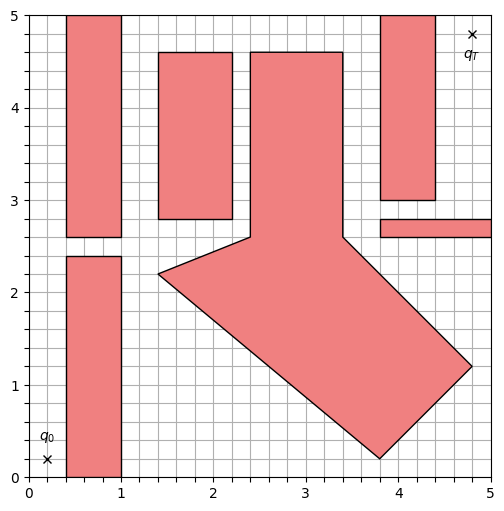

In [4]:
environment_setup()

for O in obstacles:
    plt.fill(*O.T, fc="lightcoral", ec="k", zorder=4)

plt.plot(*x_start, "kx")
plt.plot(*x_goal, "kx")

plt.text(0.2, 0.35, "$q_0$", ha="center", va="bottom")
plt.text(4.8, 4.65, "$q_T$", ha="center", va="top");

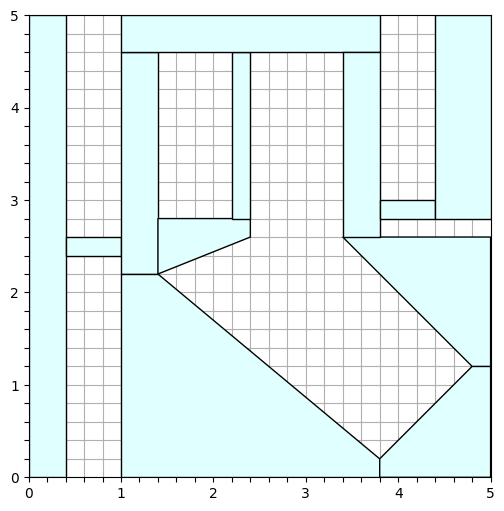

In [5]:
environment_setup()

for V in vertices:
    plt.fill(*V.T, fc="lightcyan", ec="k", zorder=4)

INFO:drake:Solved GCS shortest path using MOSEK with convex_relaxation=true and preprocessing=true and rounding.
INFO:drake:Found 2 unique paths, discarded 98 duplicate paths.
INFO:drake:Finished 2 rounding solutions with MOSEK.


result.is_success() = True
[0.0, 1e-06, 7.475153523717885, 8.075153523717885, 14.187919213654258, 19.723682862297295, 21.523682862297296, 28.056281634185673, 34.12936500397595, 34.72936500397595, 42.02951603053513, 42.029517030535125]


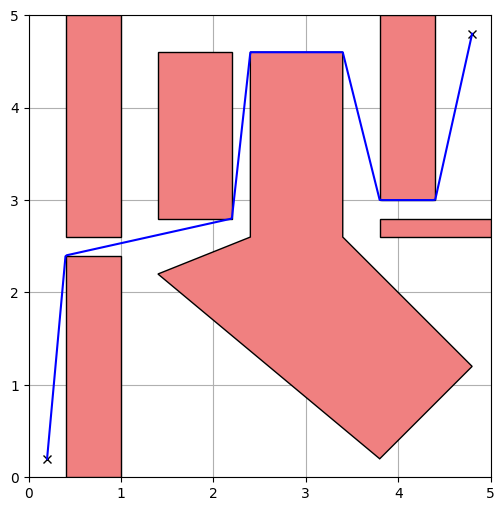

In [6]:
qdot_min = -1
qdot_max = 1


def solve_min_distance(order=1):
    trajopt = GcsTrajectoryOptimization(2)
    gcs_regions = trajopt.AddRegions(regions, order=order)
    source = trajopt.AddRegions([Point(x_start)], order=0)
    target = trajopt.AddRegions([Point(x_goal)], order=0)
    trajopt.AddEdges(source, gcs_regions)
    trajopt.AddEdges(gcs_regions, target)
    trajopt.AddPathLengthCost()
    trajopt.AddVelocityBounds([qdot_min] * 2, [qdot_max] * 2)
    options = GraphOfConvexSetsOptions()
    [traj, result] = trajopt.SolvePath(source, target, options)
    print(f"result.is_success() = {result.is_success()}")
    if result.is_success():
        print(traj.get_segment_times())
        plot_trajectory(traj)


solve_min_distance()

In [7]:
qdot_min = -1
qdot_max = 1


def solve_min_time(regions, order, continuity_order, hdot_min=1e-6, regularizer=None, velocity=None):
    gcs = BezierGCS(regions, order, continuity_order, hdot_min=hdot_min)

    gcs.addTimeCost(1)
    gcs.addVelocityLimits([qdot_min] * 2, [qdot_max] * 2)
    if regularizer is not None:
        gcs.addDerivativeRegularization(*regularizer, 2)
    gcs.addSourceTarget(x_start, x_goal, velocity=velocity)
    
    gcs.setSolver(MosekSolver())
    gcs.setPaperSolverOptions()
    
    [traj, result] = gcs.SolvePath(True)

    return traj, result

INFO:drake:Solved GCS shortest path using MOSEK with convex_relaxation=true and preprocessing=false and no rounding.


Problem
  Name                   :                 
  Objective sense        : minimize        
  Type                   : LO (linear optimization problem)
  Constraints            : 1541            
  Affine conic cons.     : 0               
  Disjunctive cons.      : 0               
  Cones                  : 0               
  Scalar variables       : 411             
  Matrix variables       : 0               
  Integer variables      : 0               

Optimizer started.
Presolve started.
Linear dependency checker started.
Linear dependency checker terminated.
Eliminator started.
Freed constraints in eliminator : 295
Eliminator terminated.
Eliminator started.
Freed constraints in eliminator : 21
Eliminator terminated.
Eliminator - tries                  : 2                 time                   : 0.00            
Lin. dep.  - tries                  : 1                 time                   : 0.00            
Lin. dep.  - primal attempts        : 1                 successes   

INFO:drake:Solved GCS shortest path using MOSEK with convex_relaxation=true and preprocessing=false and rounding.
INFO:drake:Found 3 unique paths, discarded 97 duplicate paths.
INFO:drake:Finished 3 rounding solutions with MOSEK.


12  1.3e-06  1.3e-06  2.5e-07  9.98e-01   9.879993787e+00   9.879997517e+00   1.9e-10  0.09  
13  1.3e-07  1.2e-07  2.3e-08  1.00e+00   9.879999607e+00   9.879999952e+00   1.8e-11  0.09  
14  2.9e-08  2.3e-08  4.4e-09  1.00e+00   9.879999925e+00   9.879999991e+00   3.4e-12  0.10  
15  8.8e-09  7.4e-08  9.0e-11  1.00e+00   9.880000001e+00   9.879999999e+00   6.2e-14  0.10  
16  8.8e-09  7.4e-08  9.0e-11  1.00e+00   9.880000001e+00   9.879999999e+00   6.2e-14  0.11  
Basis identification started.
Basis identification initialization started.
Basis identification initialization terminated. Time: 0.00
Primal basis identification phase started.
Primal basis identification phase terminated. Time: 0.00
Dual basis identification phase started.
Dual basis identification phase terminated. Time: 0.00
Initialization.                            Time: 0.00        
Primal.          Iterations: 16            Time: 0.00        
Dual.            Iterations: 116           Time: 0.00        
Optimization. 

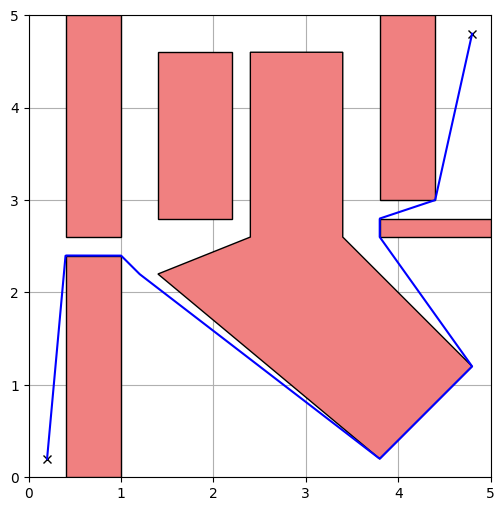

In [8]:
order = 1
continuity = 0
traj, results = solve_min_time(regions, order, continuity)

plot_trajectory(traj)

# plot_velocity(traj)


Problem
  Name                   :                 
  Objective sense        : minimize        
  Type                   : CONIC (conic optimization problem)
  Constraints            : 5558            
  Affine conic cons.     : 290 (1015 rows)
  Disjunctive cons.      : 0               
  Cones                  : 0               
  Scalar variables       : 1571            
  Matrix variables       : 0               
  Integer variables      : 0               

Optimizer started.
Presolve started.
Linear dependency checker started.
Linear dependency checker terminated.
Eliminator started.
Freed constraints in eliminator : 945
Eliminator terminated.
Eliminator started.
Freed constraints in eliminator : 123
Eliminator terminated.
Eliminator - tries                  : 2                 time                   : 0.00            
Lin. dep.  - tries                  : 1                 time                   : 0.00            
Lin. dep.  - primal attempts        : 1                 successes 

INFO:drake:Solved GCS shortest path using MOSEK with convex_relaxation=true and preprocessing=false and no rounding.


42  2.0e-06  1.2e-05  2.9e-08  1.01e+00   2.660490687e+01   2.660455610e+01   1.2e-08  1.56  
43  1.5e-06  9.0e-06  1.9e-08  1.00e+00   2.661582938e+01   2.661557186e+01   1.1e-08  1.59  
44  1.5e-06  9.0e-06  1.9e-08  1.00e+00   2.661582938e+01   2.661557186e+01   1.1e-08  1.63  
45  4.3e-07  1.4e-06  1.6e-09  1.00e+00   2.661744544e+01   2.661740594e+01   1.7e-09  1.66  
Optimizer terminated. Time: 1.66    


Interior-point solution summary
  Problem status  : PRIMAL_AND_DUAL_FEASIBLE
  Solution status : OPTIMAL
  Primal.  obj: 2.6617445439e+01    nrm: 1e+03    Viol.  con: 8e-01    var: 0e+00    acc: 3e-02  
  Dual.    obj: -6.0565476304e+03   nrm: 2e+21    Viol.  con: 5e-08    var: 6e+03    acc: 0e+00  
Problem
  Name                   :                 
  Objective sense        : minimize        
  Type                   : CONIC (conic optimization problem)
  Constraints            : 5558            
  Affine conic cons.     : 290 (1015 rows)
  Disjunctive cons.      : 0           

INFO:drake:Solved GCS shortest path using MOSEK with convex_relaxation=true and preprocessing=false and rounding.
INFO:drake:Found 4 unique paths, discarded 96 duplicate paths.


40  8.6e-06  5.2e-05  2.1e-07  1.04e+00   2.655662450e+01   2.655511040e+01   2.8e-08  1.50  
41  3.0e-06  1.8e-05  5.0e-08  1.04e+00   2.659057489e+01   2.659005342e+01   1.4e-08  1.53  
42  2.0e-06  1.2e-05  2.9e-08  1.01e+00   2.660490687e+01   2.660455610e+01   1.2e-08  1.57  
43  1.5e-06  9.0e-06  1.9e-08  1.00e+00   2.661582938e+01   2.661557186e+01   1.1e-08  1.60  
44  1.5e-06  9.0e-06  1.9e-08  1.00e+00   2.661582938e+01   2.661557186e+01   1.1e-08  1.64  
45  4.3e-07  1.4e-06  1.6e-09  1.00e+00   2.661744544e+01   2.661740594e+01   1.7e-09  1.67  
Optimizer terminated. Time: 1.67    


Interior-point solution summary
  Problem status  : PRIMAL_AND_DUAL_FEASIBLE
  Solution status : OPTIMAL
  Primal.  obj: 2.6617445439e+01    nrm: 1e+03    Viol.  con: 8e-01    var: 0e+00    acc: 3e-02  
  Dual.    obj: -6.0565476304e+03   nrm: 2e+21    Viol.  con: 5e-08    var: 6e+03    acc: 0e+00  
Problem
  Name                   :                 
  Objective sense        : minimize        


INFO:drake:Finished 4 rounding solutions with MOSEK.


2   2.5e+02  1.3e-01  1.2e+00  -9.81e-01  3.598156193e+01   3.893090148e+01   2.5e-01  0.03  
3   1.4e+02  6.9e-02  8.4e-01  -9.27e-01  8.971004657e+01   9.796968944e+01   1.4e-01  0.03  
2   2.6e+02  1.3e-01  1.2e+00  -9.81e-01  3.372924564e+01   3.639965270e+01   2.6e-01  0.03  
2   2.5e+02  1.3e-01  1.2e+00  -9.80e-01  3.618182695e+01   3.903679921e+01   2.5e-01  0.03  
3   1.5e+02  7.6e-02  8.9e-01  -9.24e-01  8.324442826e+01   9.037388847e+01   1.5e-01  0.03  
4   2.8e+01  1.4e-02  2.9e-01  -8.17e-01  4.127099337e+02   4.477364270e+02   2.8e-02  0.03  
3   1.6e+02  7.8e-02  9.1e-01  -9.32e-01  7.976182478e+01   8.667584882e+01   1.6e-01  0.03  
3   1.5e+02  7.8e-02  9.0e-01  -9.22e-01  8.452770840e+01   9.144846801e+01   1.6e-01  0.03  
5   1.0e+01  5.2e-03  1.0e-01  -2.03e-01  6.422593070e+02   6.733965002e+02   1.0e-02  0.04  
4   5.3e+01  2.7e-02  4.5e-01  -8.32e-01  2.757220552e+02   2.965647575e+02   5.3e-02  0.04  
4   5.6e+01  2.8e-02  4.7e-01  -8.41e-01  2.583764715e+02   

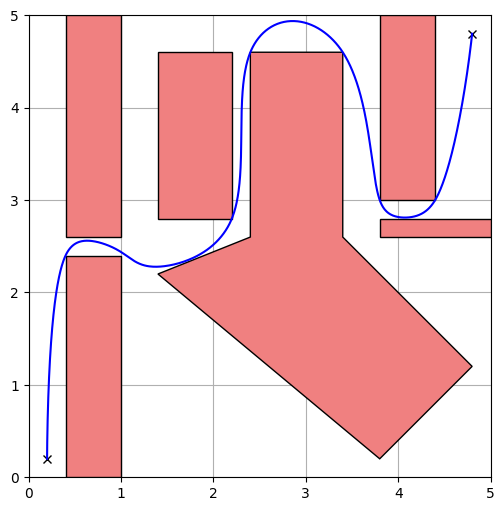

In [9]:
order = 6
continuity = 2
velocity = np.zeros((2, 2))
regularizer = [1e-1, 1e-1]
traj, results = solve_min_time(regions, order, continuity, velocity=velocity, regularizer=regularizer)

plot_trajectory(traj)

# plot_velocity(traj)

## Approximate Convex Decomposition of Polygons

In [13]:
%load_ext autoreload
%autoreload 2

from acd2d.acd2d import ACD2D

# Setup
acd = ACD2D()
acd.set_parameters(tau=0.0)

x_start = np.array([0.2, 0.2])
x_goal = np.array([4.8, 4.8])
convex_relaxation = True

workspace = np.array([[0, 0], [5, 0], [5, 5], [0, 5]])
# Original obstacles
obstacles = [
    np.array([
        [3.4, 2.6],
        [3.4, 4.6],
        [2.4, 4.6],
        [2.4, 2.6],
        [1.4, 2.2],
        [3.8, 0.2],
        [4.8, 1.2],
    ]),
    np.array([[1.4, 2.8], [2.2, 2.8], [2.2, 4.6], [1.4, 4.6]]),
    np.array([[1.0, 2.6], [1.0, 5.0], [0.4, 5.0], [0.4, 2.6]]),
    np.array([[1.0, 2.4], [1.0, 0.0], [0.4, 0.0], [0.4, 2.4]]),
    np.array([[3.8, 3.0], [3.8, 5.0], [4.4, 5.0], [4.4, 3.0]]),
    np.array([[3.8, 2.8], [3.8, 2.6], [5.0, 2.6], [5.0, 2.8]]),
]

regions, results_CD = acd.decompose_to_hpolyhedron(workspace, holes=obstacles)

# Debug: Kiểm tra xem start và goal có nằm trong regions không
print(f"\nKiểm tra điểm start {x_start}:")
start_in_region = False
for i, region in enumerate(regions):
    if region.PointInSet(x_start):
        print(f"  ✓ Nằm trong region {i}")
        start_in_region = True
if not start_in_region:
    print(f"  ✗ KHÔNG nằm trong bất kỳ region nào!")

print(f"\nKiểm tra điểm goal {x_goal}:")
goal_in_region = False
for i, region in enumerate(regions):
    if region.PointInSet(x_goal):
        print(f"  ✓ Nằm trong region {i}")
        goal_in_region = True
if not goal_in_region:
    print(f"  ✗ KHÔNG nằm trong bất kỳ region nào!")

order = 1
continuity = 0
traj, results = solve_min_time(regions, order, continuity)

plot_trajectory(traj)


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
ACD2D wrapper initialized with executable: /home/dang-khoa/code/motion-planning/gcs-science-robotics/acd2d/build/acd2d
Input file saved to: acd2d_input_1763997439.poly
Decomposed into 15 polygons with 16 cuts.

Polygon 1:
[[1.15886  0.790131]
 [1.31688  0.737455]
 [1.31688  1.31688 ]
 [1.15886  1.31688 ]]

Polygon 2:
[[0.895481 1.21153 ]
 [1.00083  1.31688 ]
 [0.263387 1.31688 ]
 [0.632114 1.21153 ]]

Polygon 3:
[[0.579429 1.21153 ]
 [0.591127 1.22323 ]
 [0.263377 1.31687 ]
 [0.263377 1.23261 ]
 [0.368738 1.21153 ]]

Polygon 4:
[[0.632104 1.21152 ]
 [0.591127 1.22323 ]
 [0.579429 1.21153 ]
 [0.579429 0.737455]
 [0.632104 0.68478 ]]

Polygon 5:
[[0.368728  0.579429 ]
 [0.263377  0.632104 ]
 [0.263377  0.       ]
 [1.00322   0.       ]
 [1.00083   0.0526754]]

Polygon 6:
[[ 0.00000e+00  1.31688e+00]
 [ 0.00000e+00 -2.92407e-16]
 [ 1.05351e-01  6.84780e-01]
 [ 1.05351e-01  1.31688e+00]]

Polygon 7:
[[1

ValueError: Source vertex is not connected.

## VCC

In [ ]:
def BuildEnvironment():
    builder = RobotDiagramBuilder(time_step=0)
    parser = builder.parser()
    ConfigureParser(parser)
    parser.AddModelsFromUrl("package://manipulation/simple_2d_cspace.xml")
    builder.plant().Finalize()

    visualizer = ConnectPlanarSceneGraphVisualizer(
        builder.builder(),
        builder.scene_graph(),
        xlim=[-0.1, 5.1],
        ylim=[-0.1, 5.1],
        T_VW=np.array([[1, 0, 0, 0], [0, 1, 0, 0], [0, 0, 0, 1]]),
    )

    AddDefaultVisualization(builder.builder(), meshcat)

    return builder.Build()

def CliqueCoverDemo():
    meshcat.SetCameraTarget([0, 0, 0])
    meshcat.Set2dRenderMode(
        X_WC=RigidTransform([0, 0, 5]), xmin=0, xmax=5, ymin=0, ymax=5
    )
    diagram = BuildEnvironment()
    context = diagram.CreateDefaultContext()
    diagram.ForcedPublish(context)

    generator = RandomGenerator(1234)
    checker = SceneGraphCollisionChecker(
        model=diagram,
        robot_model_instances=[diagram.plant().GetModelInstanceByName("robot")],
        edge_step_size=0.01,
    )
    options = IrisFromCliqueCoverOptions()
    options.num_points_per_visibility_round = 200
    options.coverage_termination_threshold = 0.96
    
    # Đo thời gian tạo coverage
    print("=== BẮT ĐẦU TẠO VÙNG AN TOÀN VỚI CLIQUE COVER ===")
    coverage_start = time.time()
    clique_regions = IrisInConfigurationSpaceFromCliqueCover(checker, options, generator, [])
    coverage_time = time.time() - coverage_start
    print(f"Số vùng tìm được: {len(clique_regions)}")
    
    # Vẽ các vùng
    diagram.GetSubsystemByName("planar_scenegraph_visualizer")
    for region in clique_regions:
        V = VPolytope(region)
        hull = ConvexHull(V.vertices().T)
        plt.fill(
            V.vertices()[0, hull.vertices],
            V.vertices()[1, hull.vertices],
            fc="lightcyan",
            ec="k",
            zorder=4,
        )
    plt.axis("square")
    plt.xlim([x_min[0], x_max[0]])
    plt.ylim([x_min[1], x_max[1]])
    plt.xticks(range(6))
    plt.yticks(range(6))
    plt.grid(1)

    # Giải trajectory với Clique Cover regions
    order = 6
    continuity = 2
    velocity = np.zeros((2, 2))
    regularizer = [1e-1, 1e-1]
    
    print("\n=== GIẢI TRAJECTORY VỚI CLIQUE COVER ===")
    solve_start = time.time()
    traj_clique, results_clique = solve_min_time(clique_regions, order, continuity, velocity=velocity, regularizer=regularizer)
    solve_time_clique = time.time() - solve_start
    path_cost_clique = traj_clique.end_time() - traj_clique.start_time()
    
    print(f"Thời gian giải: {solve_time_clique:.4f}s")
    print(f"Chi phí đường đi (thời gian di chuyển): {path_cost_clique:.4f}s")
    
    plot_trajectory(traj_clique)
    
    # So sánh với phân hoạch thủ công
    print("\n=== GIẢI TRAJECTORY VỚI PHÂN HOẠCH THỦ CÔNG ===")
    solve_start = time.time()
    traj_manual, results_manual = solve_min_time(regions, order, continuity, velocity=velocity, regularizer=regularizer)
    solve_time_manual = time.time() - solve_start
    path_cost_manual = traj_manual.end_time() - traj_manual.start_time()
    
    print(f"Số vùng: {len(regions)}")
    print(f"Thời gian giải: {solve_time_manual:.4f}s")
    print(f"Chi phí đường đi: {path_cost_manual:.4f}s")
    print(f"Thời gian tạo coverage: {coverage_time:.4f}s")
    # Bảng so sánh
    print("\n" + "="*70)
    print("                    BẢNG SO SÁNH KẾT QUẢ")
    print("="*70)
    print(f"{'Phương pháp':<25} {'Số vùng':<12} {'T.gian giải (s)':<18} {'Chi phí (s)':<15}")
    print("-"*70)
    print(f"{'Clique Cover':<25} {len(clique_regions):<12} {solve_time_clique:<18.4f} {path_cost_clique:<15.4f}")
    print(f"{'Phân hoạch thủ công':<25} {len(regions):<12} {solve_time_manual:<18.4f} {path_cost_manual:<15.4f}")
    print("-"*70)
    
    # So sánh tổng thời gian
    total_time_clique = coverage_time + solve_time_clique
    total_time_manual = solve_time_manual  # không có thời gian tạo coverage
    
    print(f"{'Tổng thời gian':<25} {'(bao gồm tạo coverage)'}")
    print(f"{'Clique Cover':<25} {'':<12} {total_time_clique:<18.4f}")
    print(f"{'Phân hoạch thủ công':<25} {'':<12} {total_time_manual:<18.4f}")
    print("="*70)
    
    # Kết luận
    if path_cost_clique < path_cost_manual:
        print(f"\n✓ Clique Cover cho đường đi TỐT HƠN ({path_cost_clique:.4f}s < {path_cost_manual:.4f}s)")
    else:
        print(f"\n✓ Phân hoạch thủ công cho đường đi TỐT HƠN ({path_cost_manual:.4f}s < {path_cost_clique:.4f}s)")
CliqueCoverDemo()

: 

: 